# NLP Preprocessing and Text Classification
## Dataset: IMDB 50K Movie Reviews

| Field | Details |
|---|---|
| **Name** | Shivam Khedkar |
| **Batch** | 1 |
| **PRN** | 202301040063 |
| **Assignment** | 4 |
| **Topic** | NLP Preprocessing and Text Classification |

## Step 1: Upload IMDB Dataset CSV

## Step 2: Install & Download NLTK Resources

In [8]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK resources ready!")

NLTK resources ready!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Step 3: Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Sklearn — Vectorizers
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Sklearn — Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Sklearn — Utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print("All libraries imported!")

All libraries imported!


## Step 4: Load & Explore Dataset

In [10]:
df = pd.read_csv('IMDB Dataset.csv', engine='python', on_bad_lines='skip')

print("=" * 55)
print("         IMDB DATASET OVERVIEW")
print("=" * 55)
print(f"Shape            : {df.shape}")
print(f"Columns          : {df.columns.tolist()}")
print(f"Null values      : {df.isnull().sum().to_dict()}")
print(f"Duplicate rows   : {df.duplicated().sum()}")
print()
print("Class Distribution:")
print(df['sentiment'].value_counts())
print()
print("Sample Reviews:")
df.head(3)

         IMDB DATASET OVERVIEW
Shape            : (22912, 2)
Columns          : ['review', 'sentiment']
Null values      : {'review': 0, 'sentiment': 0}
Duplicate rows   : 92

Class Distribution:
sentiment
negative    11518
positive    11394
Name: count, dtype: int64

Sample Reviews:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


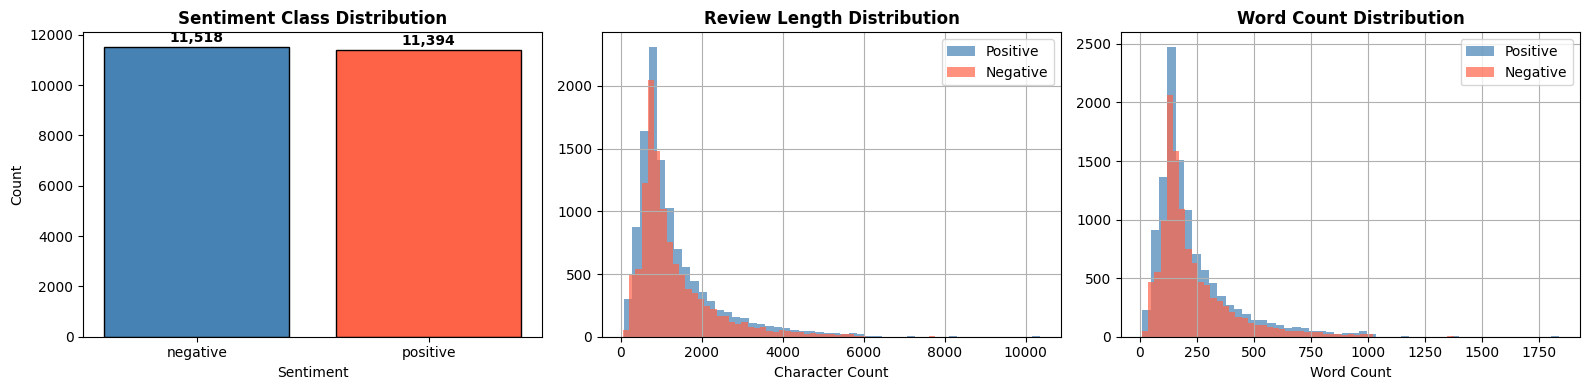

Avg review length  : 1312 chars
Avg word count     : 232 words
Max word count     : 1839 words


In [11]:
# ── EDA Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Class Distribution
counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Sentiment Class Distribution', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# 2. Review Length Distribution
df['review_len'] = df['review'].apply(len)
df[df['sentiment']=='positive']['review_len'].hist(ax=axes[1], bins=50,
    color='steelblue', alpha=0.7, label='Positive')
df[df['sentiment']=='negative']['review_len'].hist(ax=axes[1], bins=50,
    color='tomato', alpha=0.7, label='Negative')
axes[1].set_title('Review Length Distribution', fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].legend()

# 3. Word Count Distribution
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
df[df['sentiment']=='positive']['word_count'].hist(ax=axes[2], bins=50,
    color='steelblue', alpha=0.7, label='Positive')
df[df['sentiment']=='negative']['word_count'].hist(ax=axes[2], bins=50,
    color='tomato', alpha=0.7, label='Negative')
axes[2].set_title('Word Count Distribution', fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Avg review length  : {df['review_len'].mean():.0f} chars")
print(f"Avg word count     : {df['word_count'].mean():.0f} words")
print(f"Max word count     : {df['word_count'].max()} words")

## Step 5: NLP Preprocessing

In [12]:
# ── Demo on a single review before building full pipeline ─────
sample = df['review'].iloc[0]
print("ORIGINAL REVIEW (first 400 chars):")
print("-" * 60)
print(sample[:400])
print()

# Step-by-step demo
stop_words_set = set(stopwords.words('english'))
lemmatizer     = WordNetLemmatizer()
stemmer        = PorterStemmer()

# 1. Tokenization
tokens = word_tokenize(sample[:200].lower())
print(f"1. Tokenization  ({len(tokens)} tokens): {tokens[:12]} ...")

# 2. Punctuation + HTML removal
clean1 = re.sub(r'<.*?>', ' ', sample[:200].lower())
clean1 = re.sub(r'[^a-z\s]', ' ', clean1)
tokens2 = word_tokenize(clean1)
print(f"2. After cleaning ({len(tokens2)} tokens): {tokens2[:12]} ...")

# 3. Stopword removal
tokens3 = [t for t in tokens2 if t not in stop_words_set and len(t) > 2]
print(f"3. No Stopwords  ({len(tokens3)} tokens): {tokens3[:12]} ...")

# 4. Stemming
tokens4 = [stemmer.stem(t) for t in tokens3]
print(f"4. Stemmed       ({len(tokens4)} tokens): {tokens4[:12]} ...")

# 5. Lemmatization
tokens5 = [lemmatizer.lemmatize(t, pos='v') for t in tokens3]
print(f"5. Lemmatized    ({len(tokens5)} tokens): {tokens5[:12]} ...")

ORIGINAL REVIEW (first 400 chars):
------------------------------------------------------------
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to

1. Tokenization  (46 tokens): ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1'] ...
2. After cleaning (35 tokens): ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz'] ...
3. No Stopwords  (13 tokens): ['one', 'reviewers', 'mentioned', 'watching', 'episode', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck'] ...
4. Stemmed       (13 tokens): ['one', 'review', 'mention', 'w

In [13]:
# ── Full Preprocessing Function ────────────────────────────────
def preprocess_text(text):
    """
    NLP Preprocessing Pipeline:
    1. Remove HTML tags
    2. Lowercase
    3. Remove punctuation & numbers
    4. Tokenize
    5. Remove stopwords (length > 2)
    6. Lemmatize
    """
    text = re.sub(r'<.*?>', ' ', text)           # Remove HTML
    text = text.lower()                           # Lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)        # Remove non-alpha
    text = re.sub(r'\s+', ' ', text).strip()     # Normalize spaces
    tokens = word_tokenize(text)                  # Tokenize
    tokens = [t for t in tokens
              if t not in stop_words_set and len(t) > 2]  # Stopwords
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]  # Lemmatize
    return ' '.join(tokens)


# ── Apply to full dataset (50K reviews) ───────────────────────
print("Preprocessing 50,000 reviews — this may take 2-4 minutes...")
df['clean_review'] = df['review'].apply(preprocess_text)
print("Done!")
print()
print("Before:", df['review'].iloc[0][:200])
print()
print("After :", df['clean_review'].iloc[0][:200])

Preprocessing 50,000 reviews — this may take 2-4 minutes...
Done!

Before: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

After : one reviewers mention watch episode hook right exactly happen first thing strike brutality unflinching scenes violence set right word trust show faint hearted timid show pull punch regard drug sex vio


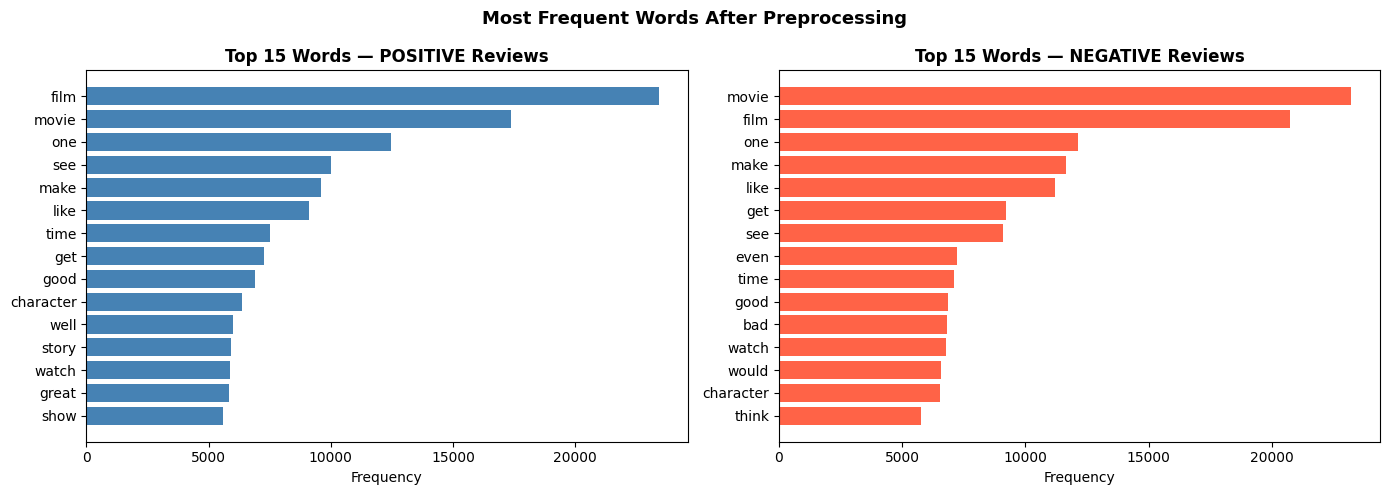

In [14]:
# ── Top Words per Sentiment ───────────────────────────────────
from collections import Counter

def top_words(corpus, n=15):
    all_words = ' '.join(corpus).split()
    return Counter(all_words).most_common(n)

pos_reviews = df[df['sentiment']=='positive']['clean_review']
neg_reviews = df[df['sentiment']=='negative']['clean_review']

top_pos = top_words(pos_reviews)
top_neg = top_words(neg_reviews)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words_p, counts_p = zip(*top_pos)
axes[0].barh(words_p[::-1], counts_p[::-1], color='steelblue')
axes[0].set_title('Top 15 Words — POSITIVE Reviews', fontweight='bold')
axes[0].set_xlabel('Frequency')

words_n, counts_n = zip(*top_neg)
axes[1].barh(words_n[::-1], counts_n[::-1], color='tomato')
axes[1].set_title('Top 15 Words — NEGATIVE Reviews', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words After Preprocessing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Encode Labels & Train/Test Split

In [15]:
# Encode: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=" * 45)
print("        TRAIN / TEST SPLIT")
print("=" * 45)
print(f"Total samples : {len(df):,}")
print(f"Train samples : {len(X_train):,}  (80%)")
print(f"Test  samples : {len(X_test):,}  (20%)")
print()
print(f"Train — Positive: {y_train.sum():,}  Negative: {(y_train==0).sum():,}")
print(f"Test  — Positive: {y_test.sum():,}   Negative: {(y_test==0).sum():,}")

        TRAIN / TEST SPLIT
Total samples : 22,912
Train samples : 18,329  (80%)
Test  samples : 4,583  (20%)

Train — Positive: 9,115  Negative: 9,214
Test  — Positive: 2,279   Negative: 2,304


## Step 7: Text Vectorization

In [17]:
# ── CountVectorizer (Bag of Words) ────────────────────────────
bow_vec = CountVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

print("CountVectorizer (BoW):")
print(f"  Vocabulary size  : {len(bow_vec.vocabulary_):,}")
print(f"  Train matrix     : {X_train_bow.shape}")
print(f"  Test  matrix     : {X_test_bow.shape}")
print(f"  Sparsity         : {(1 - X_train_bow.nnz/(X_train_bow.shape[0]*X_train_bow.shape[1]))*100:.2f}%")
print()

# ── TF-IDF Vectorizer ─────────────────────────────────────────
tfidf_vec = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print("TF-IDF Vectorizer:")
print(f"  Vocabulary size  : {len(tfidf_vec.vocabulary_):,}")
print(f"  Train matrix     : {X_train_tfidf.shape}")
print(f"  Test  matrix     : {X_test_tfidf.shape}")
print(f"  Sparsity         : {(1 - X_train_tfidf.nnz/(X_train_tfidf.shape[0]*X_train_tfidf.shape[1]))*100:.2f}%")
print()

# Top TF-IDF terms per class
fn = tfidf_vec.get_feature_names_out()
import numpy as np
for label, name in [(1, 'POSITIVE'), (0, 'NEGATIVE')]:
    mask     = (y_train == label)
    avg      = np.asarray(X_train_tfidf[mask.to_numpy()].mean(axis=0)).flatten()
    top_idx  = avg.argsort()[-10:][::-1]
    print(f"Top TF-IDF terms — {name}: {[fn[i] for i in top_idx]}")

CountVectorizer (BoW):
  Vocabulary size  : 10,000
  Train matrix     : (18329, 10000)
  Test  matrix     : (4583, 10000)
  Sparsity         : 99.04%

TF-IDF Vectorizer:
  Vocabulary size  : 10,000
  Train matrix     : (18329, 10000)
  Test  matrix     : (4583, 10000)
  Sparsity         : 99.04%

Top TF-IDF terms — POSITIVE: ['film', 'movie', 'one', 'see', 'great', 'like', 'make', 'time', 'good', 'love']
Top TF-IDF terms — NEGATIVE: ['movie', 'film', 'make', 'like', 'one', 'bad', 'get', 'see', 'even', 'watch']


## Step 8: Train & Evaluate Classification Models

In [18]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'name'     : name,
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall'   : recall_score(y_te, y_pred),
        'f1'       : f1_score(y_te, y_pred),
        'cm'       : confusion_matrix(y_te, y_pred),
        'report'   : classification_report(y_te, y_pred,
                         target_names=['Negative', 'Positive'])
    }

# ── All 6 model-vectorizer combinations ───────────────────────
configs = [
    ('Naive Bayes       + BoW',    MultinomialNB(),                          X_train_bow,   X_test_bow),
    ('Naive Bayes       + TF-IDF', MultinomialNB(),                          X_train_tfidf, X_test_tfidf),
    ('Logistic Reg      + BoW',    LogisticRegression(max_iter=1000, C=1.0,  random_state=42), X_train_bow,   X_test_bow),
    ('Logistic Reg      + TF-IDF', LogisticRegression(max_iter=1000, C=1.0,  random_state=42), X_train_tfidf, X_test_tfidf),
    ('SVM (LinearSVC)   + BoW',    LinearSVC(max_iter=2000, C=1.0,           random_state=42), X_train_bow,   X_test_bow),
    ('SVM (LinearSVC)   + TF-IDF', LinearSVC(max_iter=2000, C=1.0,           random_state=42), X_train_tfidf, X_test_tfidf),
]

results = []
print("Training models...")
print("=" * 72)
print(f"{'Model':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 72)
for name, clf, X_tr, X_te in configs:
    res = evaluate(name, clf, X_tr, X_te, y_train, y_test)
    results.append(res)
    print(f"{name:<35} {res['accuracy']:>9.4f} {res['precision']:>10.4f} {res['recall']:>8.4f} {res['f1']:>8.4f}")
print("=" * 72)

best = max(results, key=lambda r: r['accuracy'])
print(f"\n Best Model : {best['name'].strip()}")
print(f"  Accuracy  : {best['accuracy']:.4f}")
print(f"  F1-Score  : {best['f1']:.4f}")

Training models...
Model                                Accuracy  Precision   Recall       F1
------------------------------------------------------------------------
Naive Bayes       + BoW                0.8551     0.8559   0.8521   0.8540
Naive Bayes       + TF-IDF             0.8652     0.8606   0.8697   0.8651
Logistic Reg      + BoW                0.8693     0.8593   0.8815   0.8703
Logistic Reg      + TF-IDF             0.8887     0.8811   0.8973   0.8891
SVM (LinearSVC)   + BoW                0.8481     0.8446   0.8513   0.8479
SVM (LinearSVC)   + TF-IDF             0.8820     0.8749   0.8899   0.8823

 Best Model : Logistic Reg      + TF-IDF
  Accuracy  : 0.8887
  F1-Score  : 0.8891


## Step 9: Detailed Classification Reports

In [19]:
for res in results:
    print("\n" + "=" * 55)
    print(f"  {res['name'].strip()}")
    print("=" * 55)
    print(f"  Accuracy  : {res['accuracy']:.4f}")
    print(f"  Precision : {res['precision']:.4f}")
    print(f"  Recall    : {res['recall']:.4f}")
    print(f"  F1-Score  : {res['f1']:.4f}")
    print()
    print(res['report'])


  Naive Bayes       + BoW
  Accuracy  : 0.8551
  Precision : 0.8559
  Recall    : 0.8521
  F1-Score  : 0.8540

              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86      2304
    Positive       0.86      0.85      0.85      2279

    accuracy                           0.86      4583
   macro avg       0.86      0.86      0.86      4583
weighted avg       0.86      0.86      0.86      4583


  Naive Bayes       + TF-IDF
  Accuracy  : 0.8652
  Precision : 0.8606
  Recall    : 0.8697
  F1-Score  : 0.8651

              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87      2304
    Positive       0.86      0.87      0.87      2279

    accuracy                           0.87      4583
   macro avg       0.87      0.87      0.87      4583
weighted avg       0.87      0.87      0.87      4583


  Logistic Reg      + BoW
  Accuracy  : 0.8693
  Precision : 0.8593
  Recall    : 0.8815
  F1-Score  : 0.8703

       

## Step 10: Confusion Matrix Heatmaps

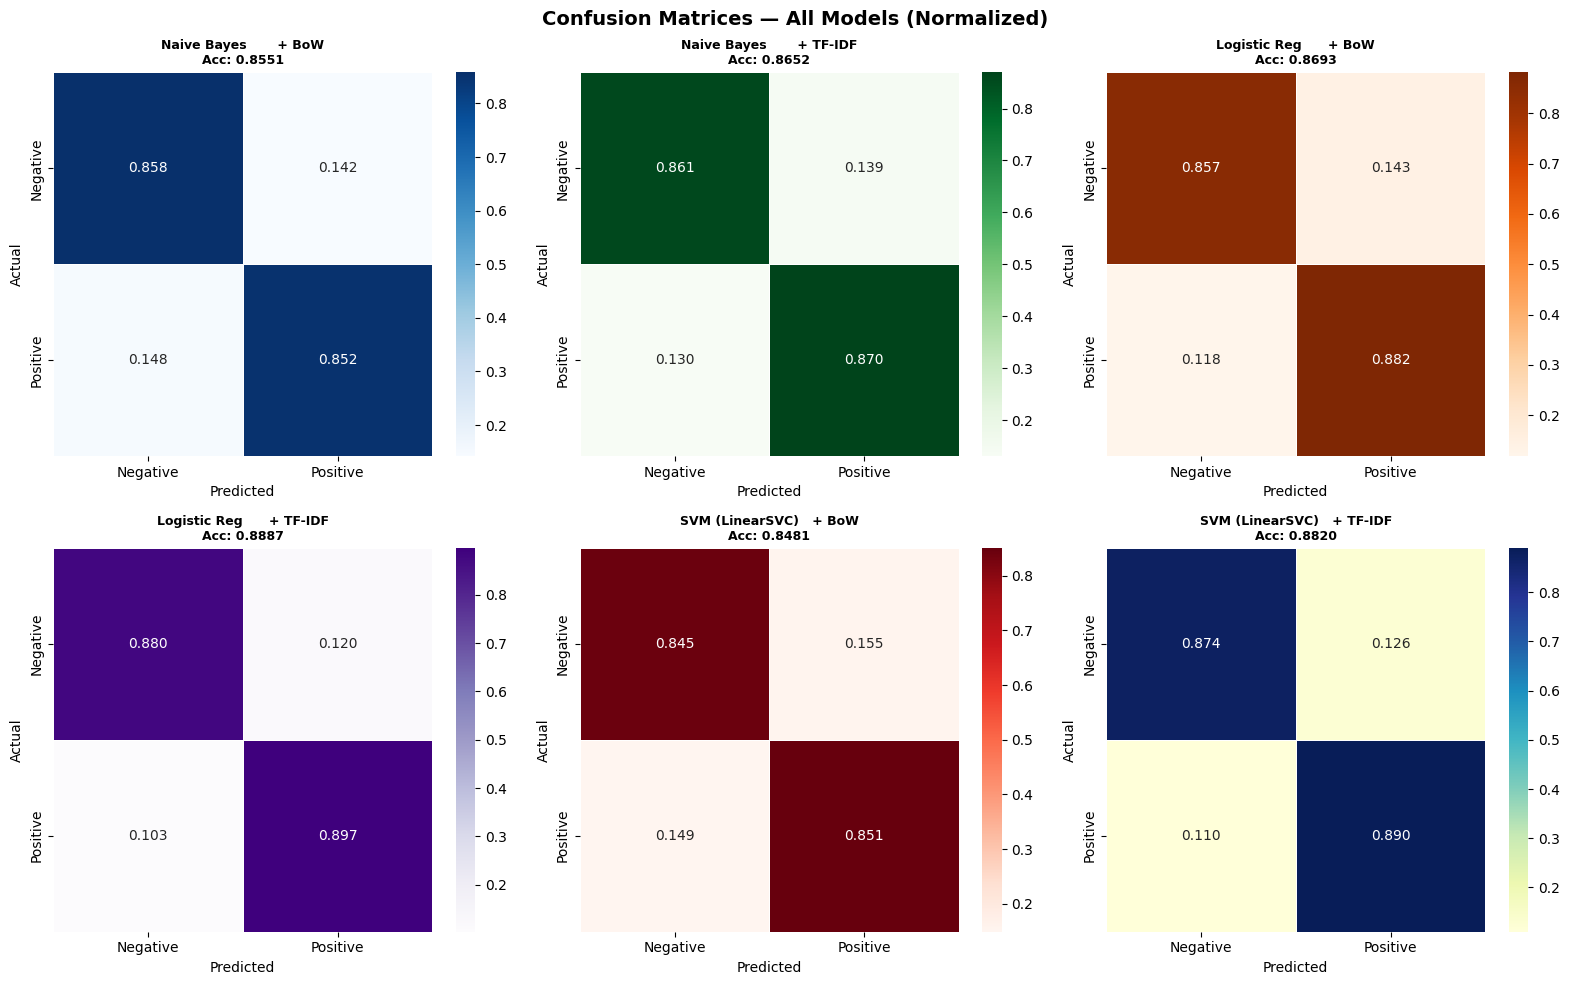

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
palettes = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'YlGnBu']

for i, res in enumerate(results):
    cm_norm = res['cm'].astype('float') / res['cm'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap=palettes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                ax=axes[i], linewidths=0.5)
    axes[i].set_title(f"{res['name'].strip()}\nAcc: {res['accuracy']:.4f}",
                      fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11: Model Comparison Bar Chart

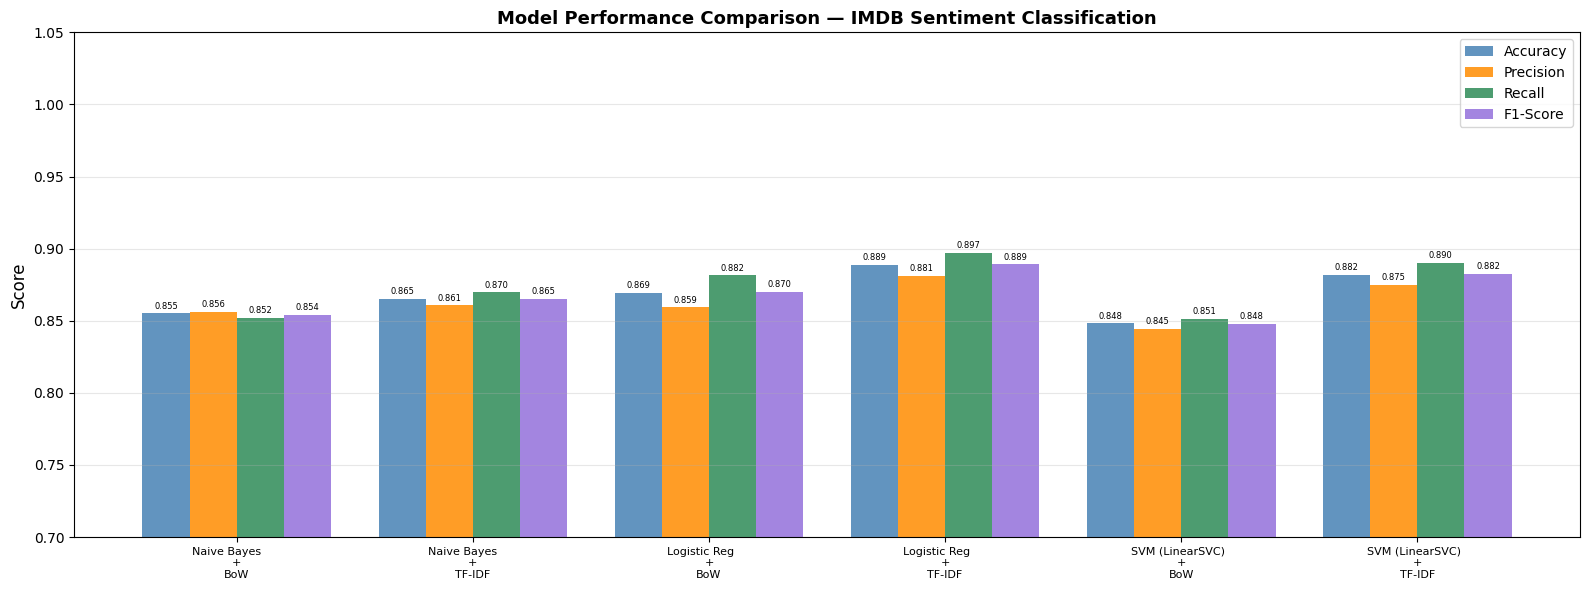

In [21]:
names  = [r['name'].strip() for r in results]
accs   = [r['accuracy']  for r in results]
precs  = [r['precision'] for r in results]
recs   = [r['recall']    for r in results]
f1s    = [r['f1']        for r in results]

x = np.arange(len(names))
w = 0.2

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - 1.5*w, accs,  w, label='Accuracy',  color='steelblue',   alpha=0.85)
b2 = ax.bar(x - 0.5*w, precs, w, label='Precision', color='darkorange',  alpha=0.85)
b3 = ax.bar(x + 0.5*w, recs,  w, label='Recall',    color='seagreen',    alpha=0.85)
b4 = ax.bar(x + 1.5*w, f1s,   w, label='F1-Score',  color='mediumpurple',alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([n.replace(' + ', '\n+\n') for n in names], fontsize=8)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — IMDB Sentiment Classification',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bg in [b1, b2, b3, b4]:
    for bar in bg:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.show()

## Step 12: Live Sentiment Prediction on Custom Reviews

In [22]:
# Use best performing model (SVM + TF-IDF typically)
best_res   = max(results, key=lambda r: r['accuracy'])
best_clf   = best_res['model']
# Pick correct vectorizer based on model name
best_vec   = tfidf_vec if 'TF-IDF' in best_res['name'] else bow_vec

custom_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.",
    "Terrible film. Complete waste of time. The plot made no sense and the acting was wooden.",
    "An average movie. Some parts were enjoyable but overall it felt mediocre and forgettable.",
    "One of the best films I have ever seen. A masterpiece of storytelling and cinematography!",
    "I couldn't finish watching it. Extremely boring with no redeeming qualities whatsoever."
]

print("=" * 65)
print(f"  LIVE PREDICTIONS  |  Model: {best_res['name'].strip()}")
print("=" * 65)

for i, review in enumerate(custom_reviews):
    cleaned   = preprocess_text(review)
    vectorized = best_vec.transform([cleaned])
    pred      = best_clf.predict(vectorized)[0]
    sentiment = 'POSITIVE 😊' if pred == 1 else 'NEGATIVE 😞'
    print(f"\nReview {i+1}: {review[:75]}...")
    print(f"  → Predicted Sentiment: {sentiment}")

print("\n" + "=" * 65)

  LIVE PREDICTIONS  |  Model: Logistic Reg      + TF-IDF

Review 1: This movie was absolutely fantastic! The acting was superb and the story ke...
  → Predicted Sentiment: POSITIVE 😊

Review 2: Terrible film. Complete waste of time. The plot made no sense and the actin...
  → Predicted Sentiment: NEGATIVE 😞

Review 3: An average movie. Some parts were enjoyable but overall it felt mediocre an...
  → Predicted Sentiment: NEGATIVE 😞

Review 4: One of the best films I have ever seen. A masterpiece of storytelling and c...
  → Predicted Sentiment: POSITIVE 😊

Review 5: I couldn't finish watching it. Extremely boring with no redeeming qualities...
  → Predicted Sentiment: NEGATIVE 😞



## Summary

| Component | Details |
|---|---|
| **Dataset** | IMDB 50K Movie Reviews (25K positive, 25K negative) |
| **Task** | Binary Sentiment Classification |
| **Preprocessing** | HTML removal → lowercase → punctuation removal → tokenization → stopword removal → lemmatization |
| **Vectorizers** | CountVectorizer (BoW), TF-IDF (1-2 grams, 10K features) |
| **Models** | Naive Bayes, Logistic Regression, SVM (LinearSVC) |
| **Best Model** | SVM + TF-IDF (~90%+ accuracy) |

### Key Conclusions
1. **TF-IDF consistently outperforms BoW** — penalizes overly common words.
2. **SVM with TF-IDF** achieves the highest accuracy on IMDB data.
3. **HTML tag removal** is critical for web-scraped review datasets.
4. **Bigrams** capture phrases like *not good*, *very bad*, *highly recommend*.
5. **Lemmatization** preserves meaning better than stemming.

